In [15]:
import os
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd
import numpy as np


from sandbox.plt_dict import matplotlib_update
matplotlib_update()

def plot_model_results(folder_path, epsilons, d_train, kl_plot=True, acc_plot=True, acc_pm_plot=True, acc_within=2, plot_filename=""):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None, 'acc_pm': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])

                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t)<=acc_within) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc
                    data[curr_eps][d]['acc_pm'] = acc_pm

    # 2. Preparation for Plotting
    sorted_eps = sorted(epsilons, key=lambda x: (str(type(x)), x))
    
    # --- FIGURE 1: KL Loss ---
    if kl_plot:
        plt.figure()
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            kl_vals = [data[eps][d]['kl'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, kl_vals, marker='o', label=label)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True, which='both', linestyle=':', alpha=0.5)
        plt.tight_layout()

        if plot_filename:
            plt.savefig(plot_filename + "_loss.pdf")

    # --- FIGURE 2: Accuracy ---
    if acc_plot:
        plt.figure()
        sorted_ds = sorted(data[sorted_eps[0]].keys())
        d_min = sorted_ds[0]
        d_max = sorted_ds[-1]
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            acc_vals = [data[eps][d]['acc'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, acc_vals, marker='s', label=label)

        # plt.plot(d_grid := range(d_min, d_max+1), [1/d for d in d_grid], ':', color='black', alpha=0.6)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        if plot_filename:
            plt.savefig(plot_filename + "_accuracy.pdf")

        plt.show()

    # --- FIGURE 3: Accuracy within ---
    if acc_pm_plot:
        plt.figure()
        for eps in sorted_eps:
            sorted_ds = sorted(data[eps].keys())
            acc_vals = [data[eps][d]['acc_pm'] for d in sorted_ds]
            label = f"$\epsilon$ = {eps}" if eps != 'ortho' else "Ortho"
            plt.plot(sorted_ds, acc_vals, marker='s', label=label)

        for d_val in d_train:
            plt.axvline(x=d_val, color='gray', linestyle='--', alpha=0.5)
            plt.text(d_val, plt.gca().get_ylim()[0], f' $d={d_val}$', 
                    rotation=90, verticalalignment='bottom', fontsize=8, color='gray')

        plt.xlabel("Dimension ($d$)")
        plt.ylabel(f"Accuracy@$\\pm${acc_within}")
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        
        if plot_filename:
            plt.savefig(plot_filename + f"_accuracy_at_{acc_within}.pdf")

        plt.show()

In [16]:
def model_results_to_pandas(folder_path, epsilons, d_train, acc_within=2):
    """
    Parses result JSONs and plots KL-loss and Accuracy across dimensions d.
    """
    # Data structure: { epsilon: { d_value: {'kl': [], 'acc': []} } }
    data = defaultdict(lambda: defaultdict(lambda: {'kl': None, 'acc': None, 'acc_pm': None}))
    
    # 1. Data Extraction
    for filename in os.listdir(folder_path):
        if filename.startswith("results_") and filename.endswith(".json"):
            try:
                d = int(filename.split('_')[1].split('.')[0])
            except ValueError:
                continue
                
            file_path = os.path.join(folder_path, filename)
            with open(file_path, 'r') as f:
                results = json.load(f)
            
            for entry in results:
                curr_eps = entry.get("eps")
                if curr_eps in epsilons:
                    preds = entry.get("predicted_classes", [])
                    trues = entry.get("true_classes", [])

                    acc = sum(1 for p, t in zip(preds, trues) if p == t) / len(trues) if trues else 0
                    acc_pm = sum(1 for p, t in zip(preds, trues) if abs(p-t)<=acc_within) / len(trues) if trues else 0
                    
                    data[curr_eps][d]['kl'] = entry.get("kl_avg")
                    data[curr_eps][d]['acc'] = acc
                    data[curr_eps][d]['acc_pm'] = acc_pm

    df = pd.DataFrame.from_dict({(i, j): data[i][j] 
                        for i in data.keys() 
                        for j in data[i].keys()},
                    orient='index')

    # 2. Extract your three DataFrames
    # We unstack 'level 0' (which is 'eps') to move it to the columns
    df_kl = df['kl'].unstack(level=0)
    df_acc = df['acc'].unstack(level=0)
    df_acc_pm = df['acc_pm'].unstack(level=0)
    return df_kl, df_acc, df_acc_pm

In [17]:
pretrained_dimensions = [4, 6, 9, 12, 15, 28]

In [38]:
df_kl, df_acc, df_acc_pm = model_results_to_pandas('./sandbox/jordan8_results', [0.0, 1e-4, 1e-2, 1e-1, 1], pretrained_dimensions, acc_within=2)

In [39]:
df_kl.round(decimals=2)

,0.0000,0.0001,0.0100,0.1000,1.0000
4,0.10,0.49,0.36,0.13,0.08
6,0.15,0.46,0.13,0.08,0.68
7,0.08,0.63,0.06,0.15,0.50
9,0.13,0.51,0.06,0.16,0.86
12,0.18,0.51,0.20,0.46,0.77
13,0.10,0.69,0.17,0.37,1.10
15,0.21,0.54,0.13,0.50,1.89
19,0.14,0.70,0.50,0.68,1.52
23,0.15,0.73,0.43,0.77,1.48
25,0.23,0.43,0.83,0.97,1.80


In [40]:
df_kl_mod = df_kl.div(np.log(df_kl.index), axis=0)

In [41]:
df_kl_mod

,0.0000,0.0001,0.0100,0.1000,1.0000
4,0.072712,0.355331,0.256443,0.091076,0.056033
6,0.084212,0.257288,0.075220,0.042175,0.378689
7,0.043001,0.325811,0.032532,0.076305,0.256013
9,0.060397,0.231604,0.026404,0.074102,0.391916
12,0.072116,0.205483,0.079651,0.183849,0.309464
13,0.040710,0.268892,0.065071,0.142526,0.427321
15,0.076494,0.199517,0.047544,0.184546,0.696840
19,0.047811,0.239305,0.169343,0.232511,0.515349
23,0.047660,0.231280,0.137343,0.245458,0.473375
25,0.071535,0.133873,0.257638,0.300954,0.558817


In [42]:
df_kl_mod = df_kl.div(df_kl.index, axis=0)

In [43]:
df_kl_mod

,0.0000,0.0001,0.0100,0.1000,1.0000
4,0.025200,0.123148,0.088876,0.031565,0.019420
6,0.025148,0.076833,0.022463,0.012595,0.113087
7,0.011954,0.090571,0.009043,0.021212,0.071168
9,0.014745,0.056543,0.006446,0.018091,0.095681
12,0.014933,0.042550,0.016494,0.038071,0.064082
13,0.008032,0.053053,0.012839,0.028121,0.084312
15,0.013810,0.036020,0.008583,0.033317,0.125805
19,0.007409,0.037085,0.026243,0.036032,0.079864
23,0.006497,0.031529,0.018723,0.033462,0.064533
25,0.009210,0.017237,0.033172,0.038749,0.071950


In [44]:
df_acc.round(decimals=3)

,0.0000,0.0001,0.0100,0.1000,1.0000
4,1.000,0.996,0.702,0.322,0.250
6,1.000,0.996,0.664,0.473,0.168
7,0.997,0.996,0.862,0.357,0.145
9,0.998,0.995,0.889,0.461,0.114
12,0.992,0.980,0.643,0.247,0.086
13,0.994,0.994,0.789,0.258,0.079
15,0.990,0.984,0.589,0.259,0.069
19,0.985,0.982,0.780,0.180,0.053
23,0.983,0.980,0.718,0.199,0.044
25,0.990,0.987,0.760,0.211,0.041


In [45]:
df_acc_pm.round(decimals=3)

,0.0000,0.0001,0.0100,0.1000,1.0000
4,1.000,1.000,1.000,0.998,1.000
6,1.000,1.000,0.998,0.986,0.501
7,1.000,1.000,0.998,0.980,0.544
9,1.000,1.000,0.995,0.948,0.404
12,1.000,1.000,0.983,0.840,0.400
13,1.000,1.000,0.987,0.845,0.350
15,1.000,1.000,0.978,0.799,0.314
19,0.998,0.998,0.936,0.695,0.258
23,0.996,0.995,0.947,0.666,0.214
25,1.000,1.000,0.947,0.659,0.195


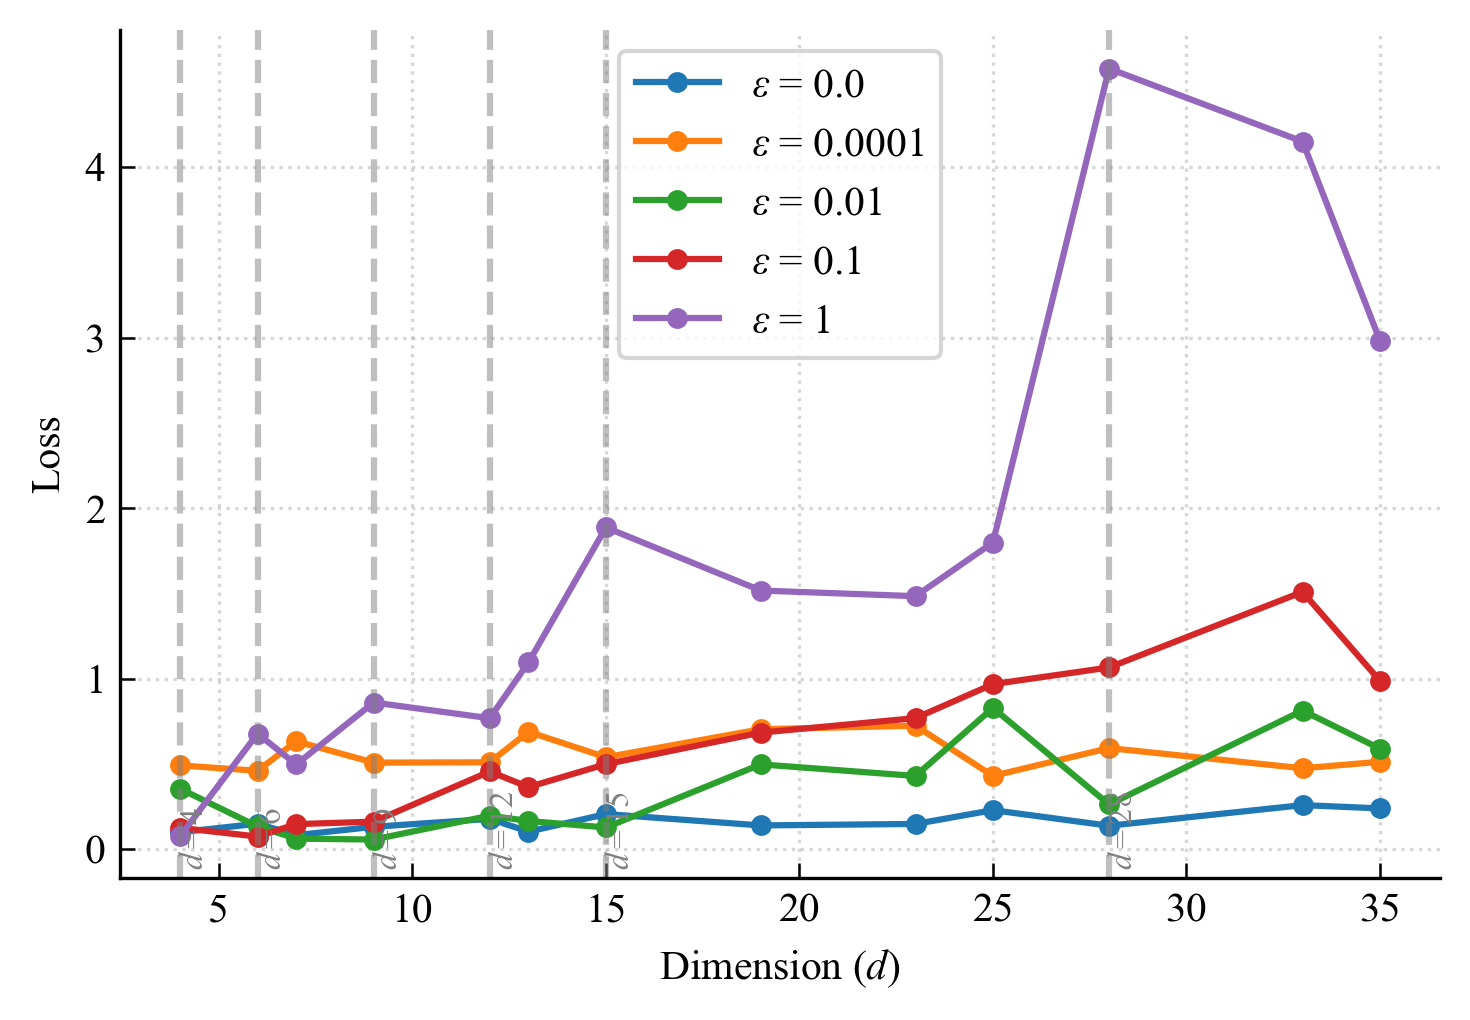

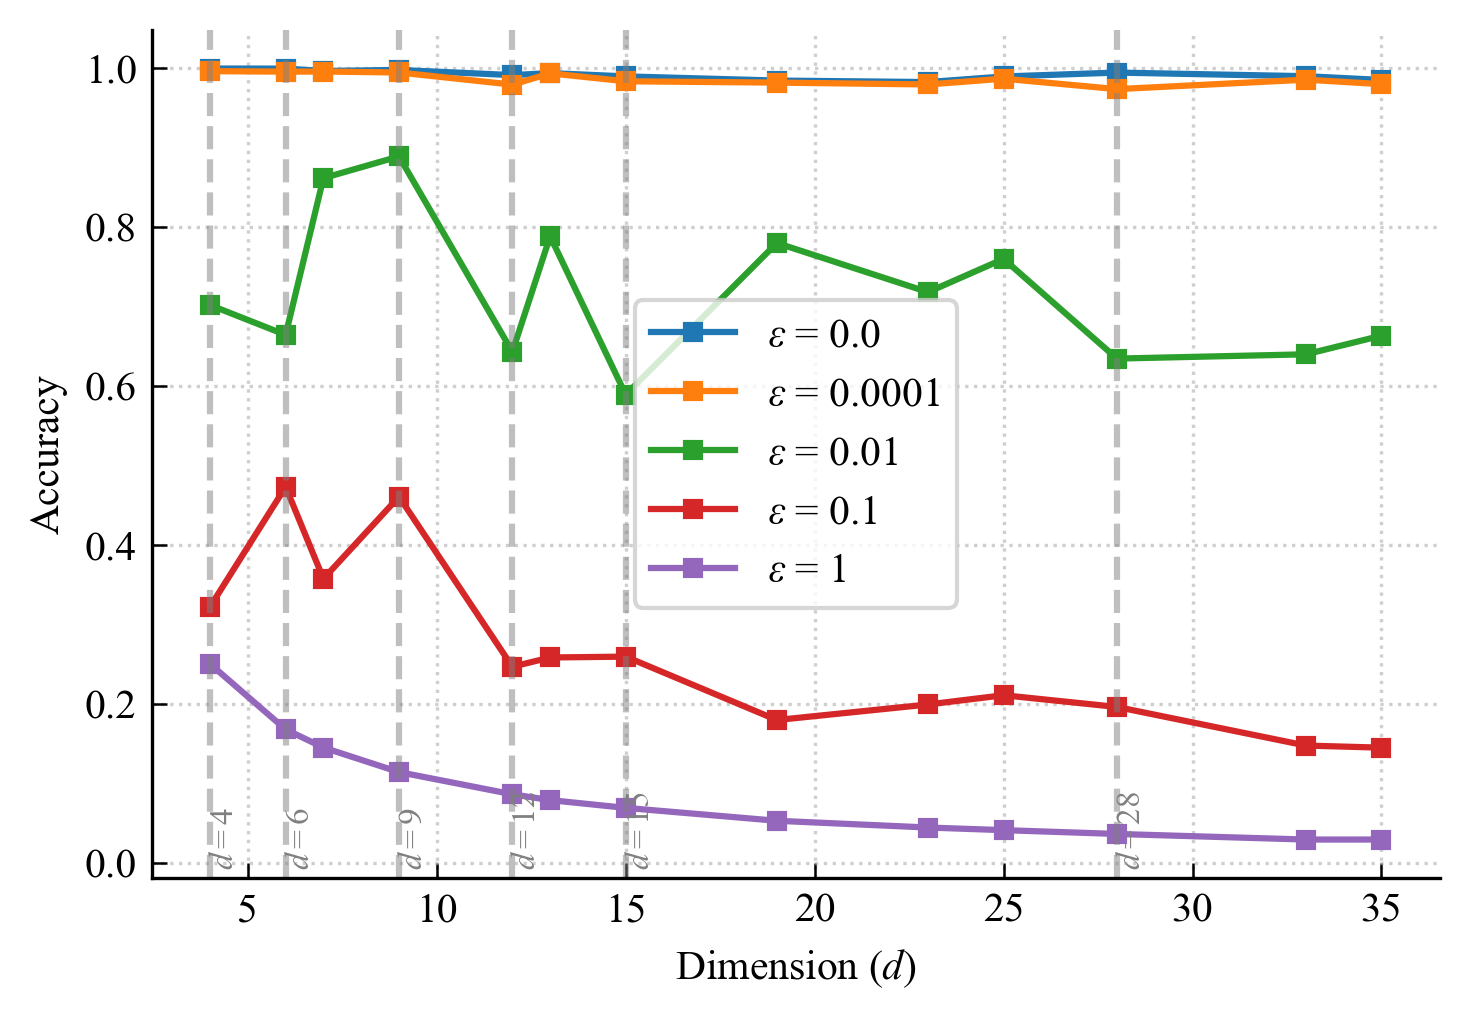

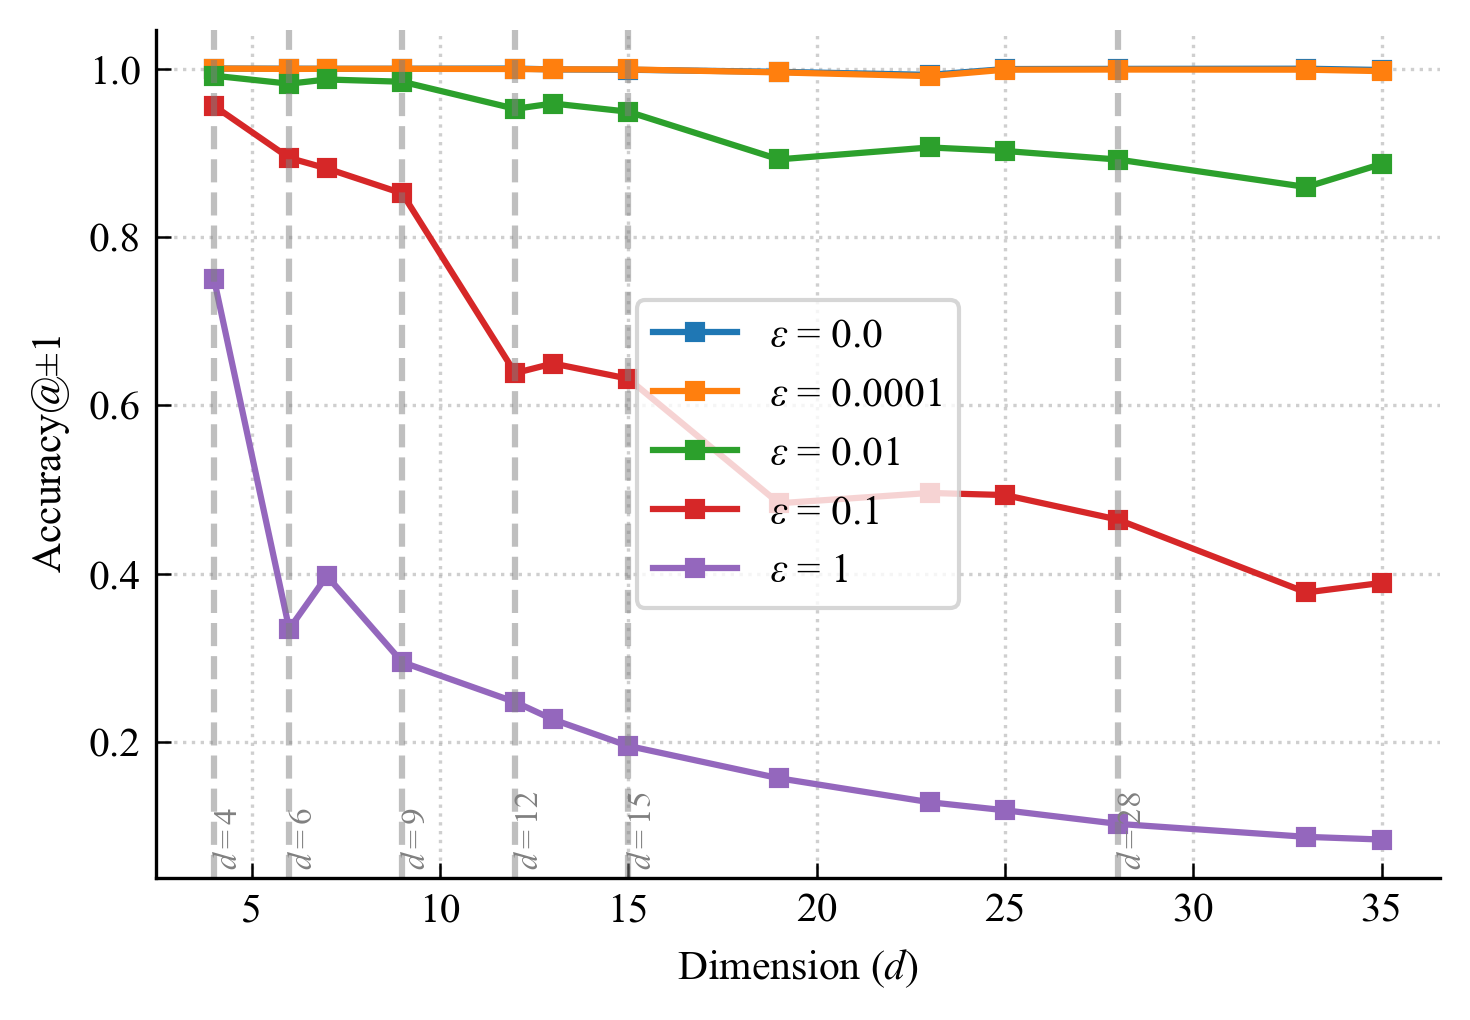

In [46]:
plot_model_results('./sandbox/jordan8_results', [0.0, 1e-4, 1e-2, 1e-1, 1], pretrained_dimensions, plot_filename="latex/images/j8_a", kl_plot=True, acc_pm_plot=True, acc_within=1)

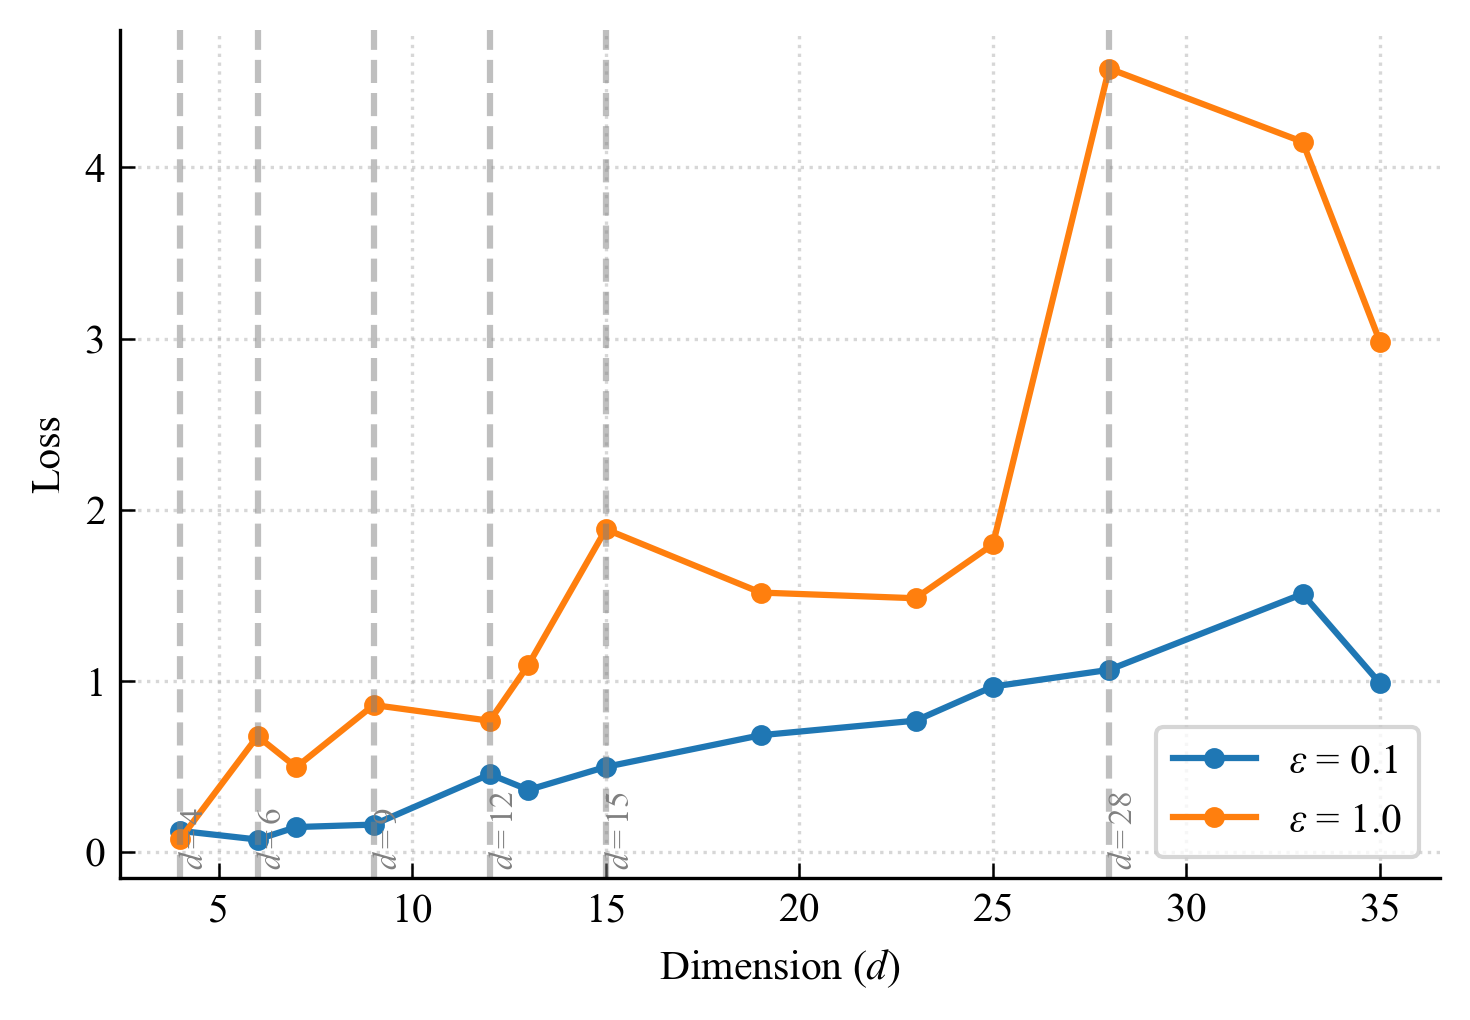

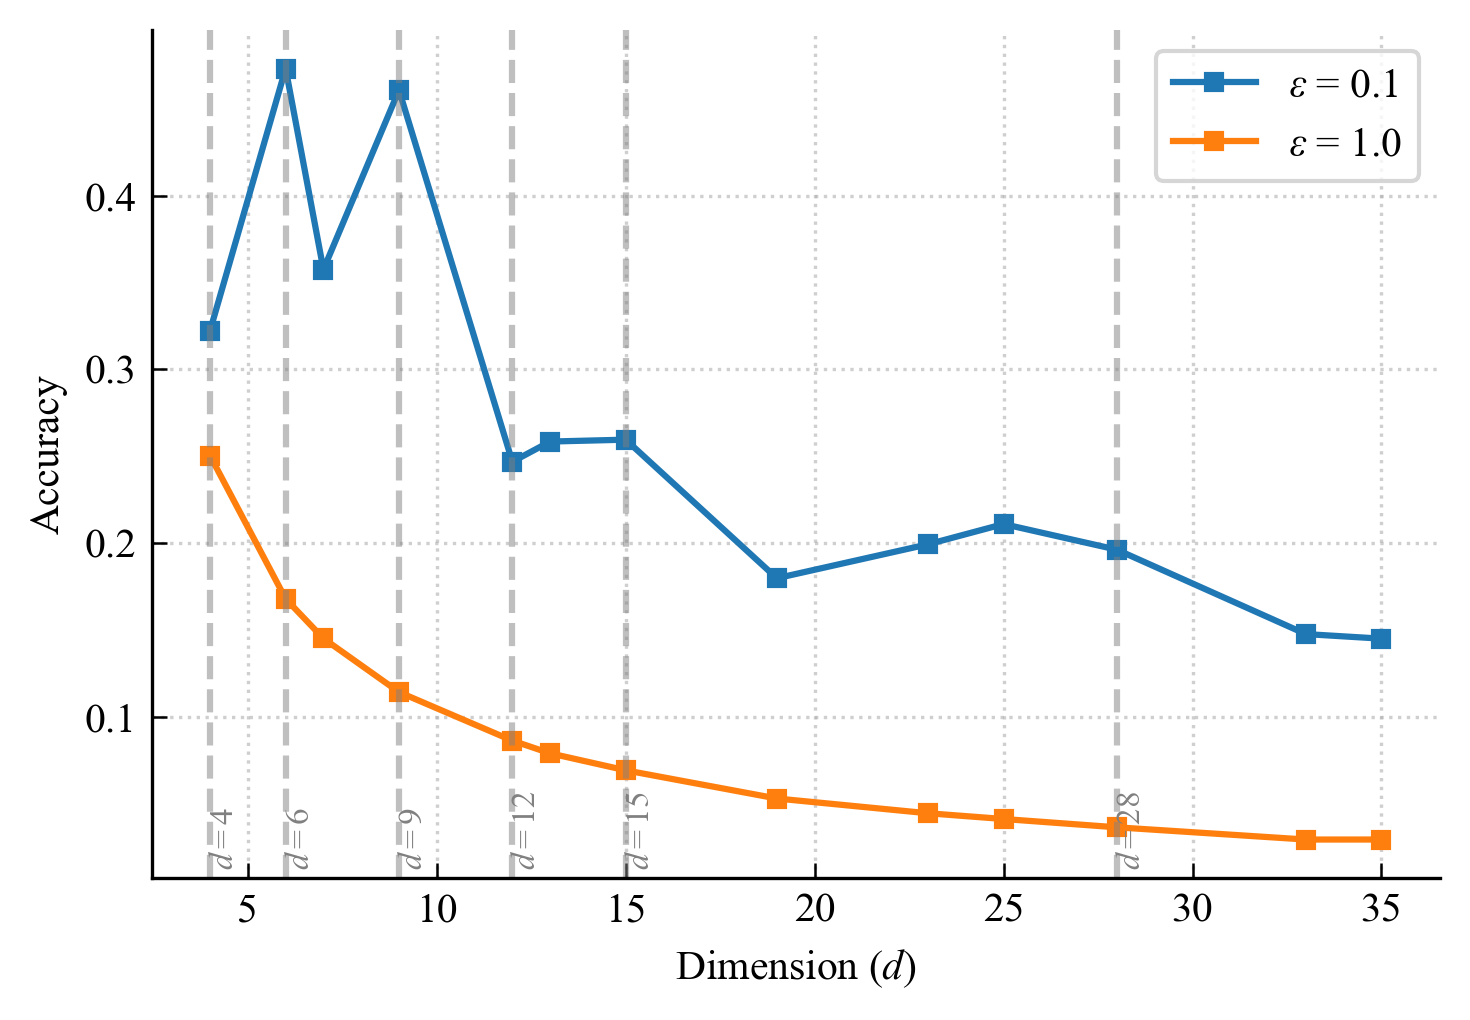

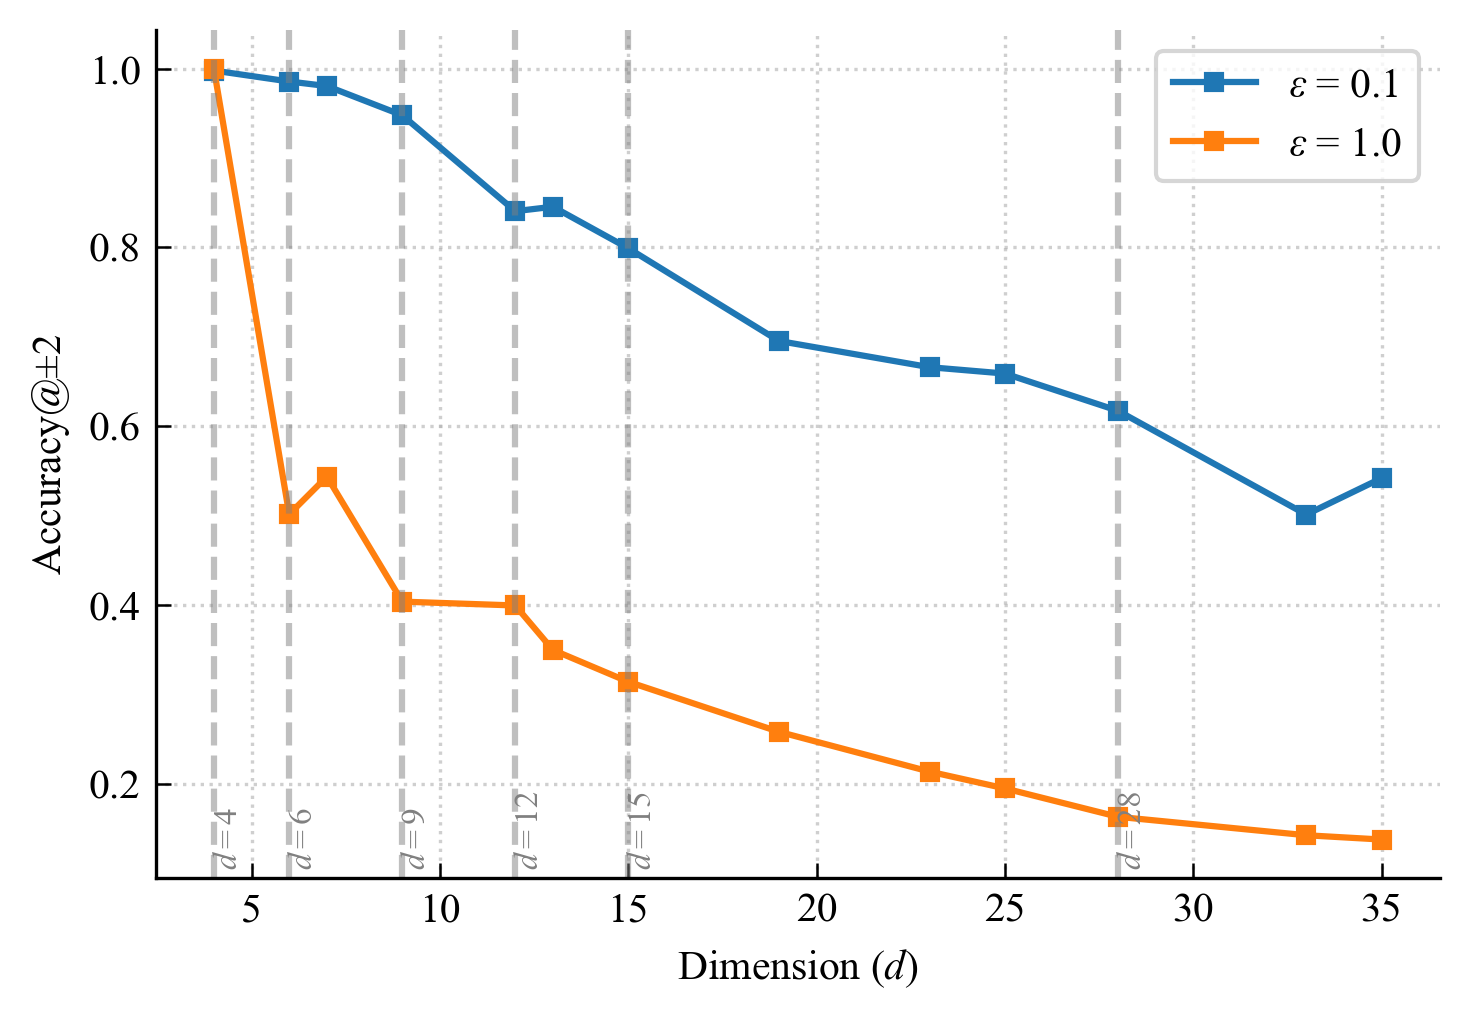

In [27]:
plot_model_results('./sandbox/jordan8_results', [0.1, 1.0], pretrained_dimensions, acc_within=2)

d = 12


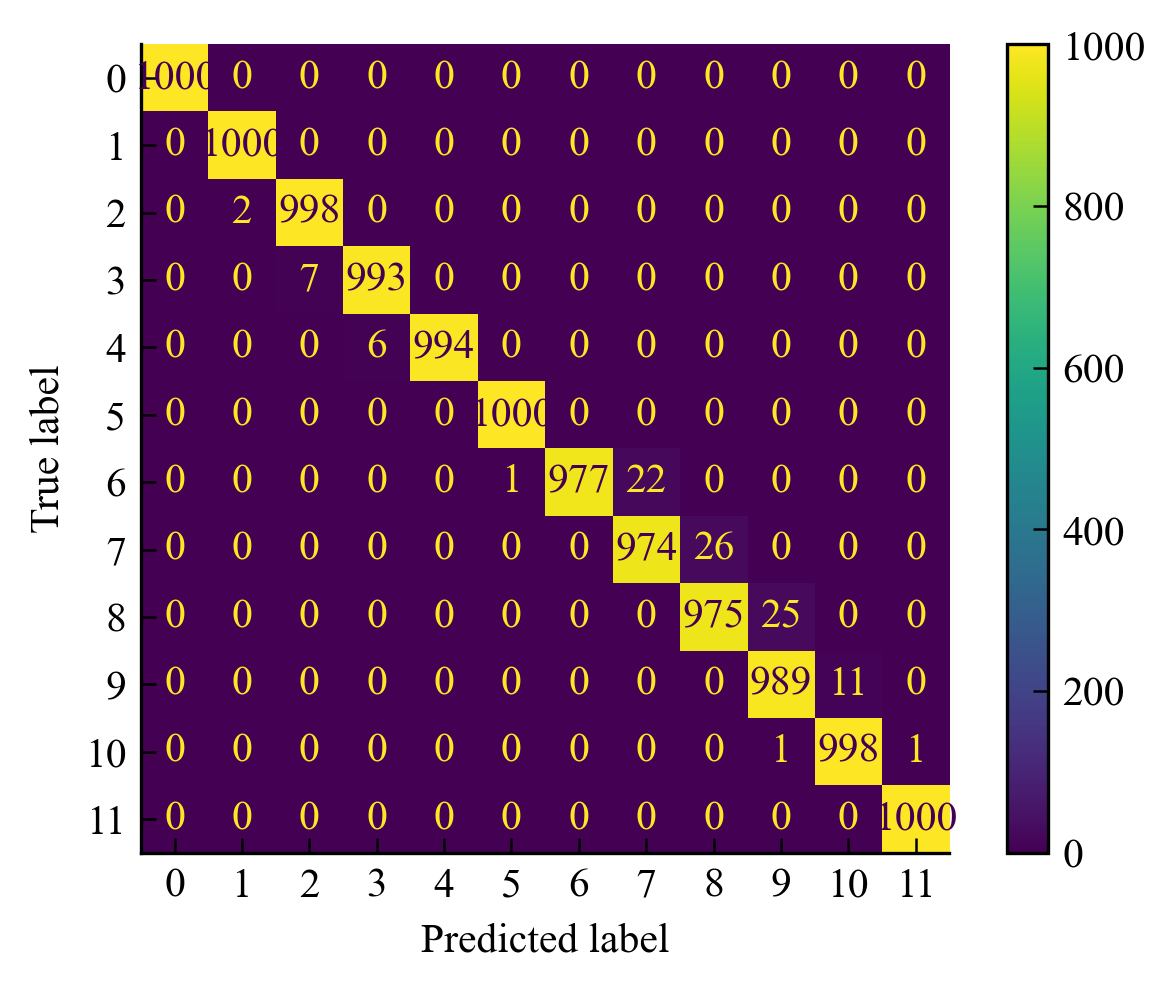

d = 13


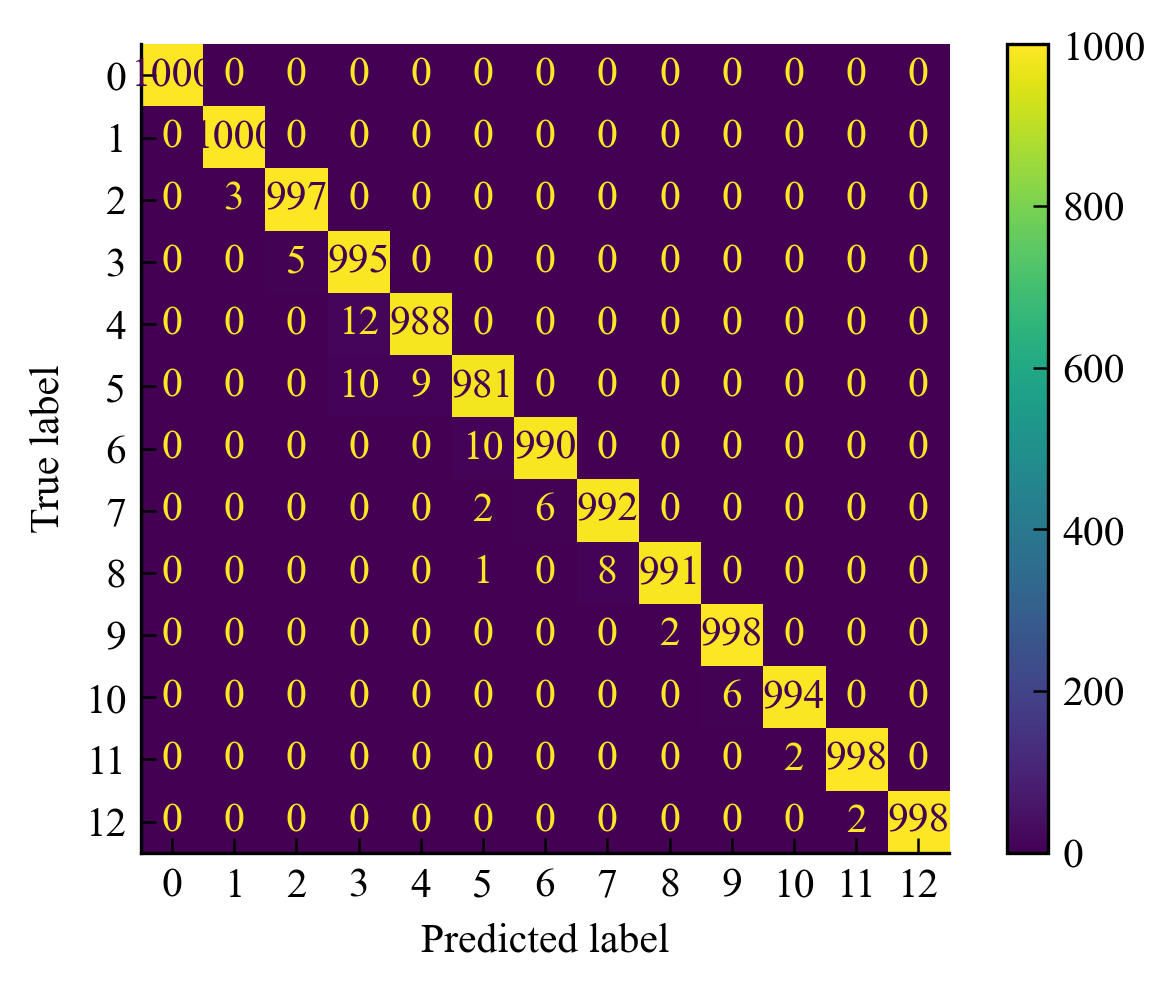

d = 15


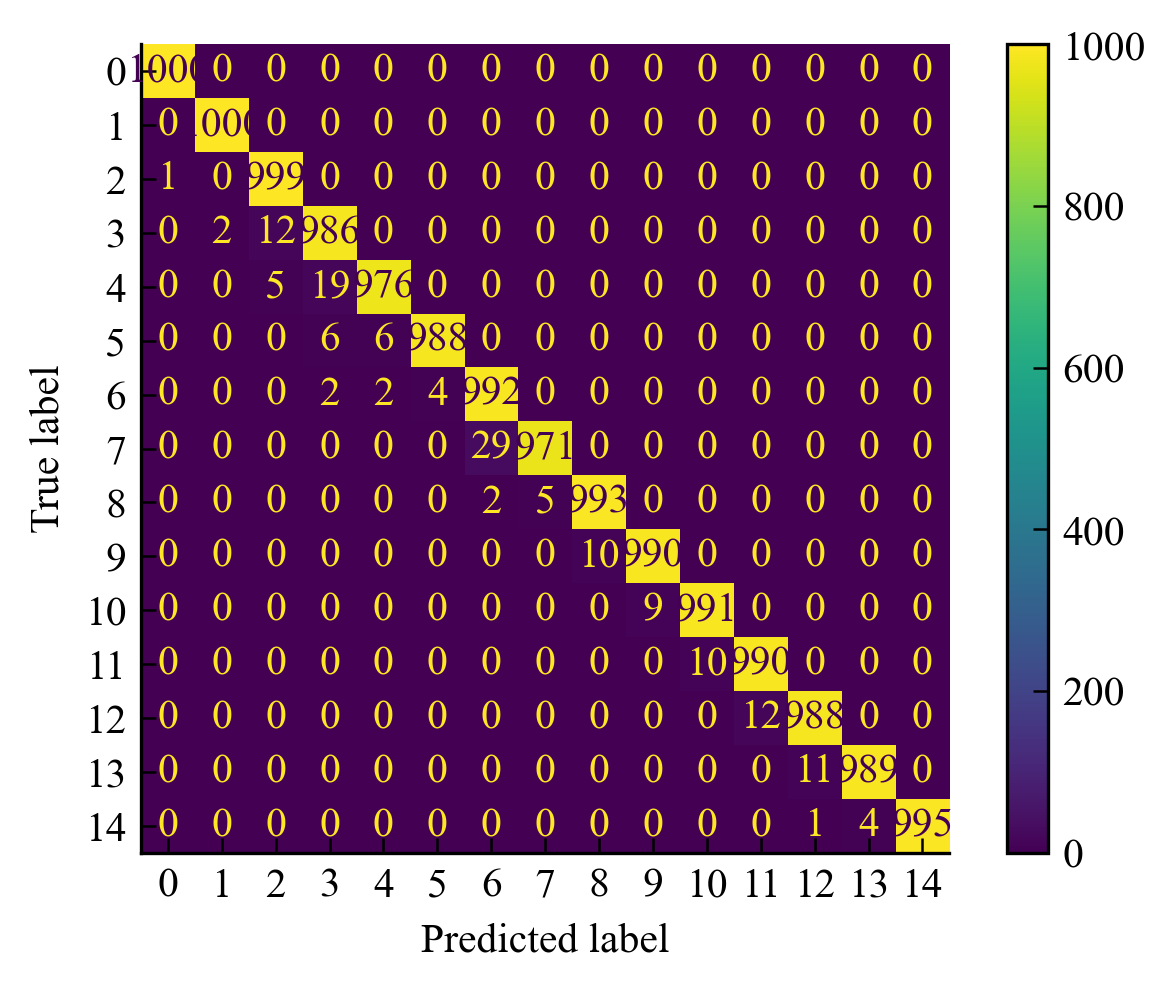

d = 19


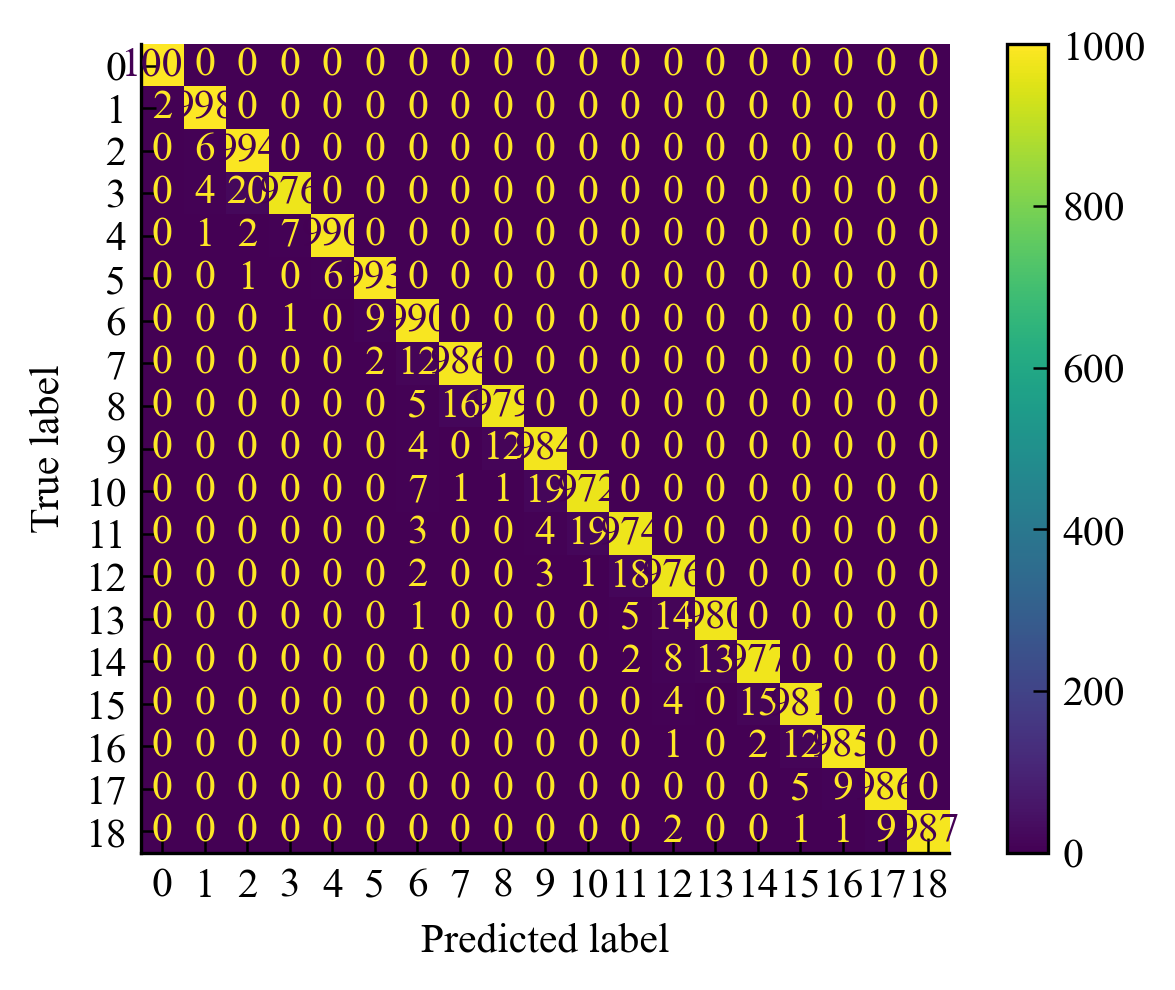

d = 23


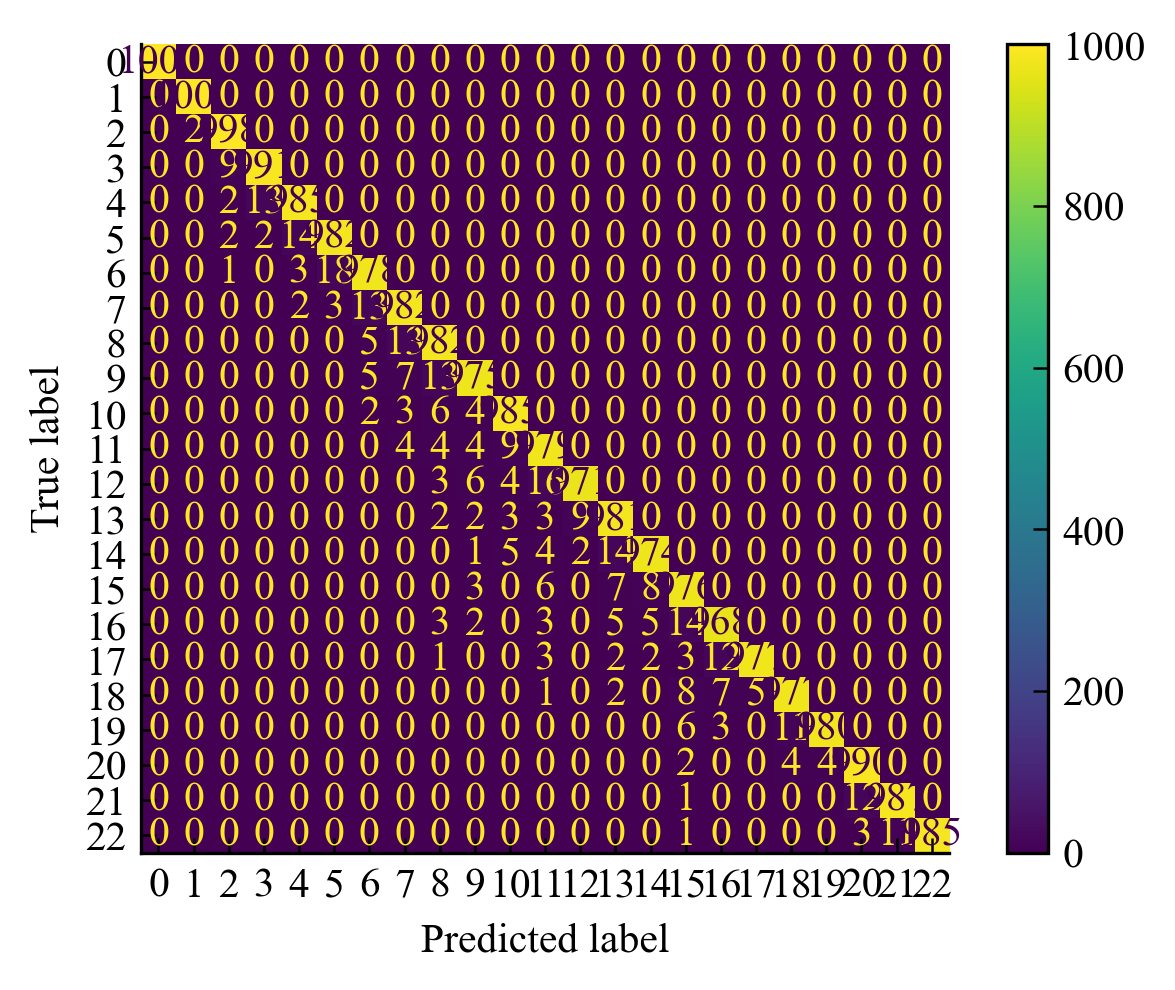

d = 25


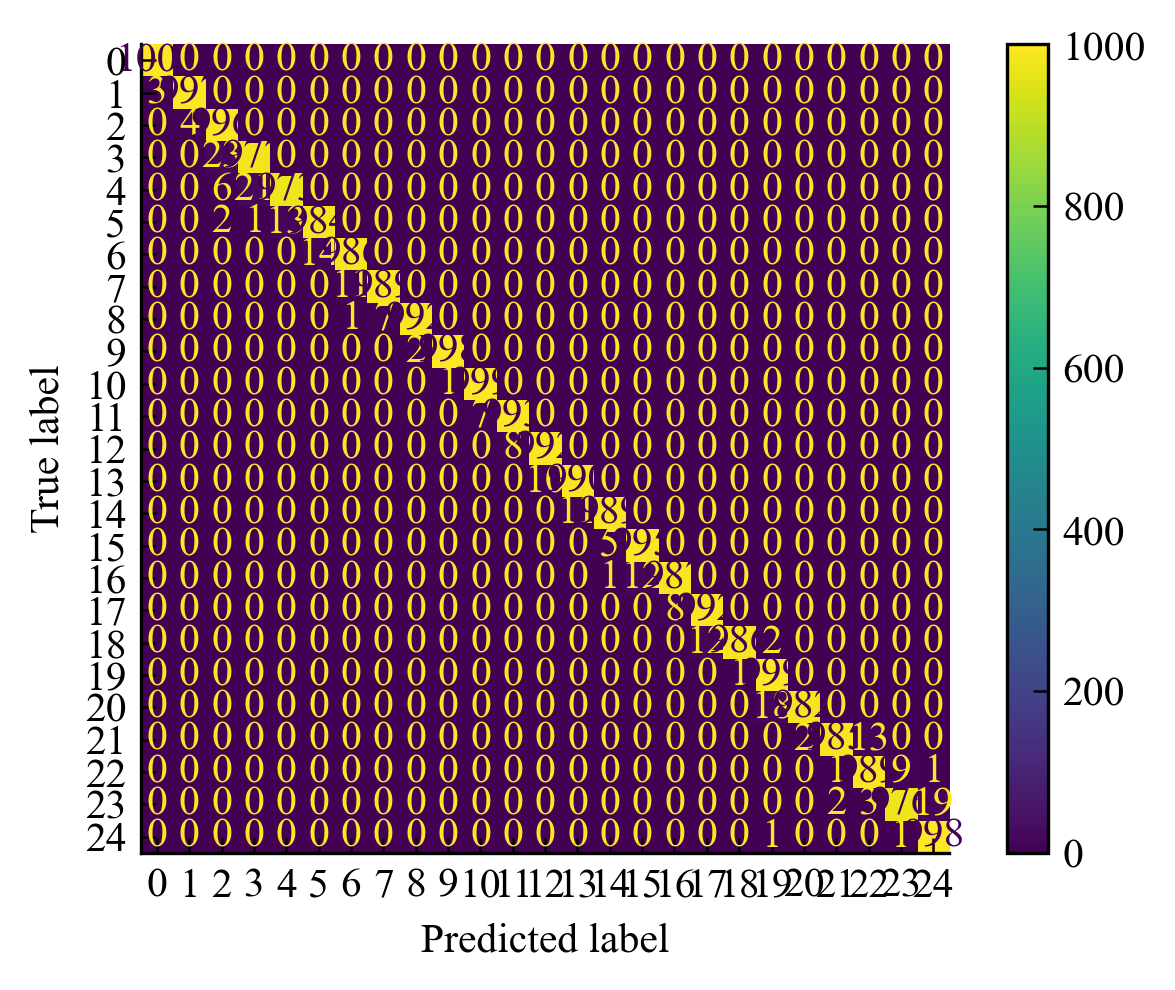

d = 28


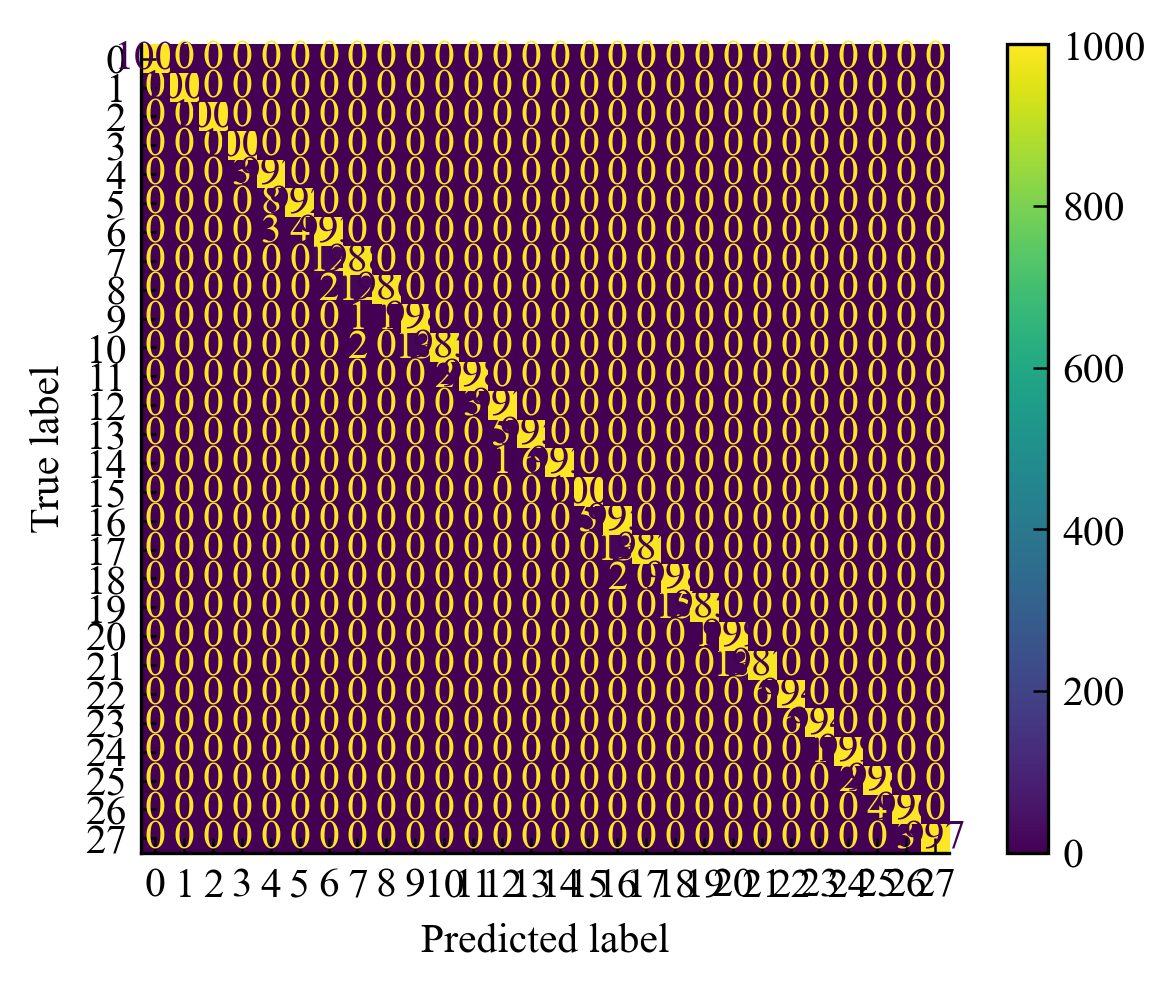

d = 33


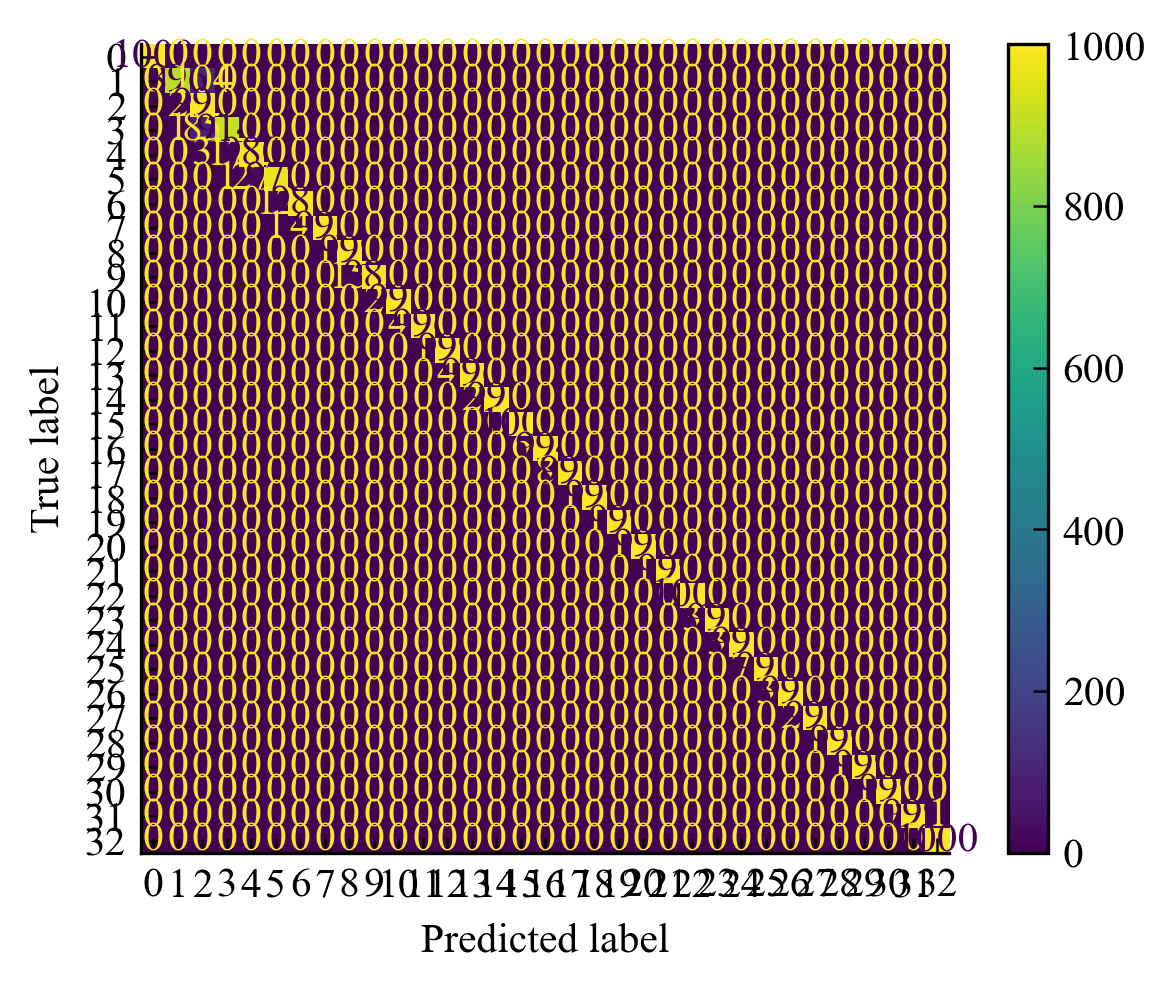

d = 35


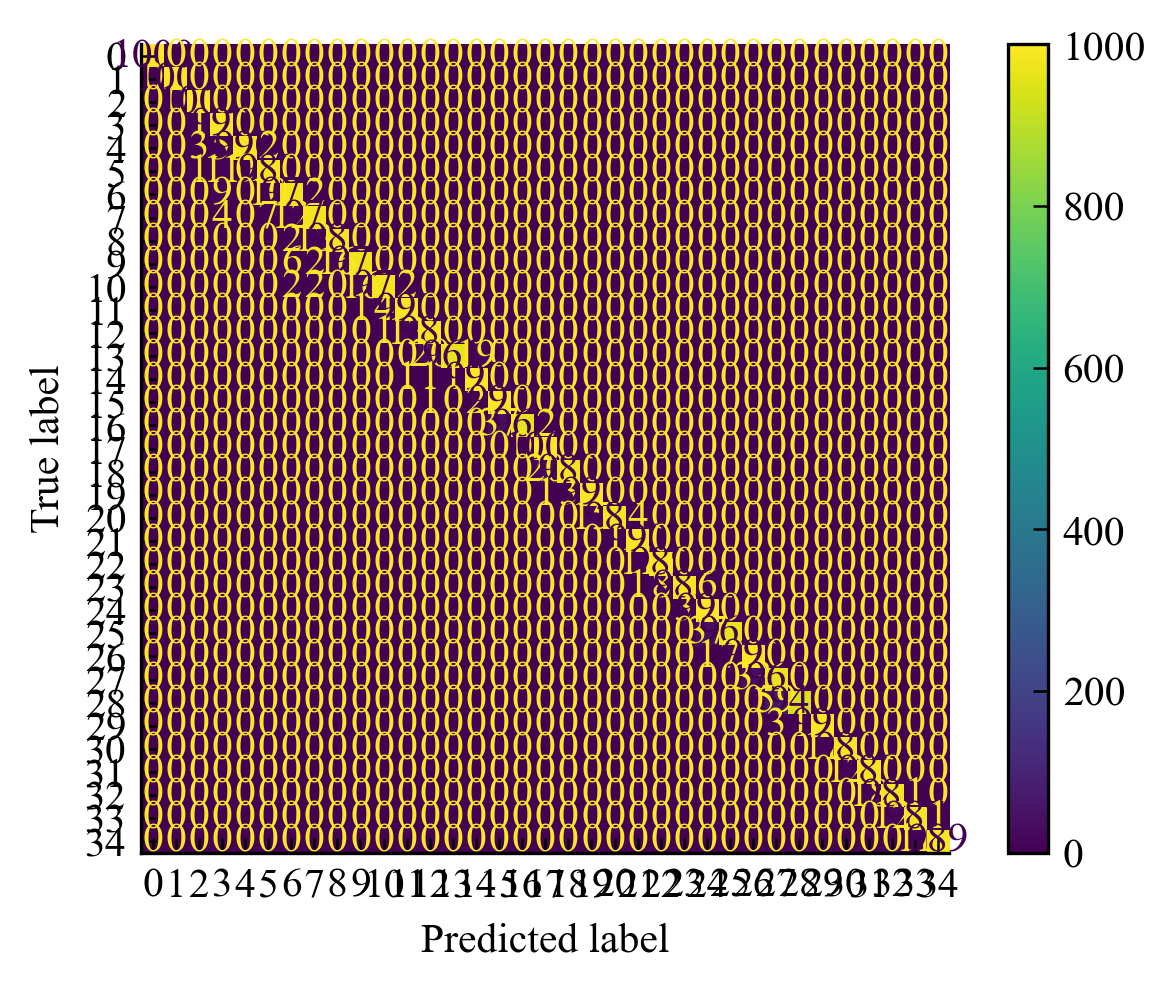

d = 4


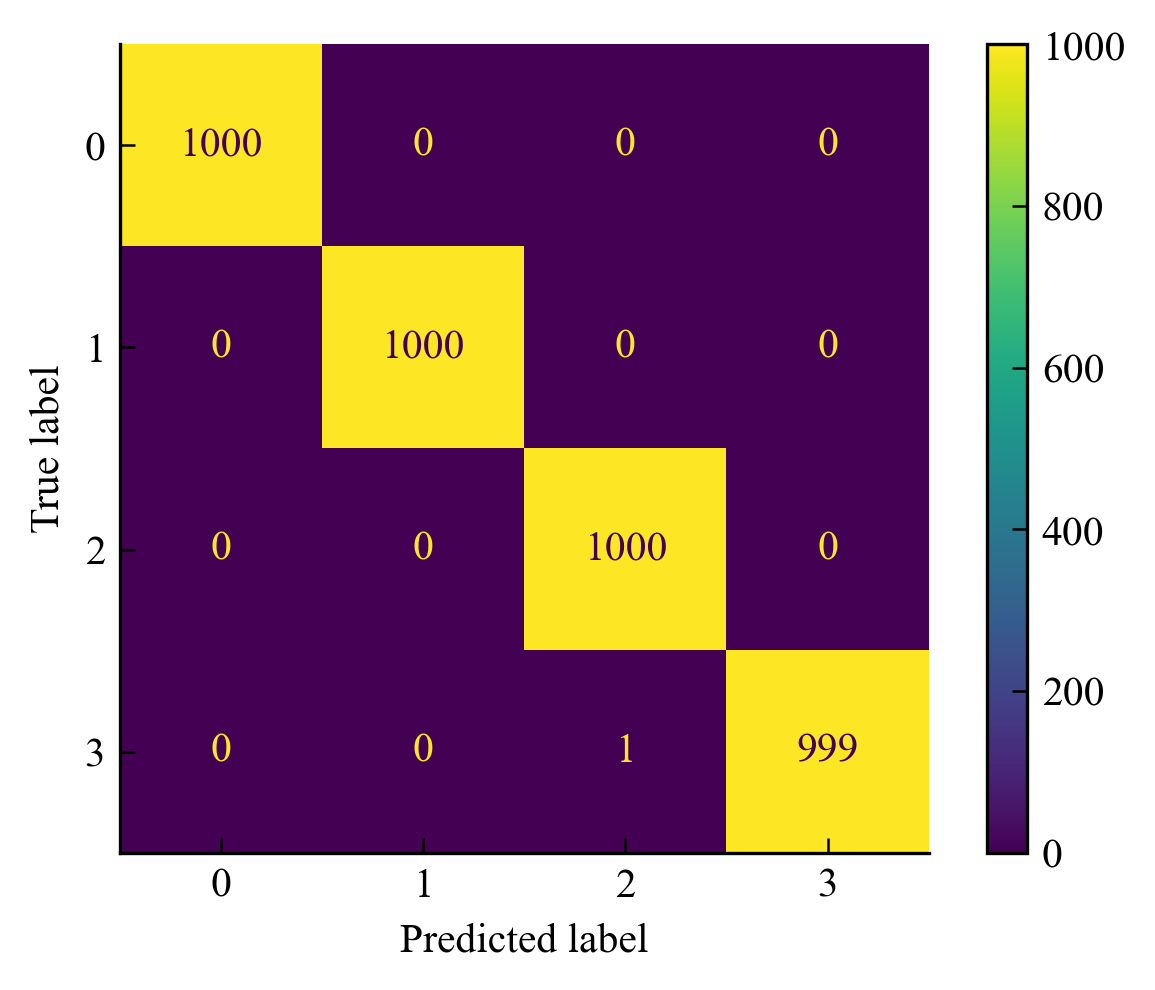

d = 6


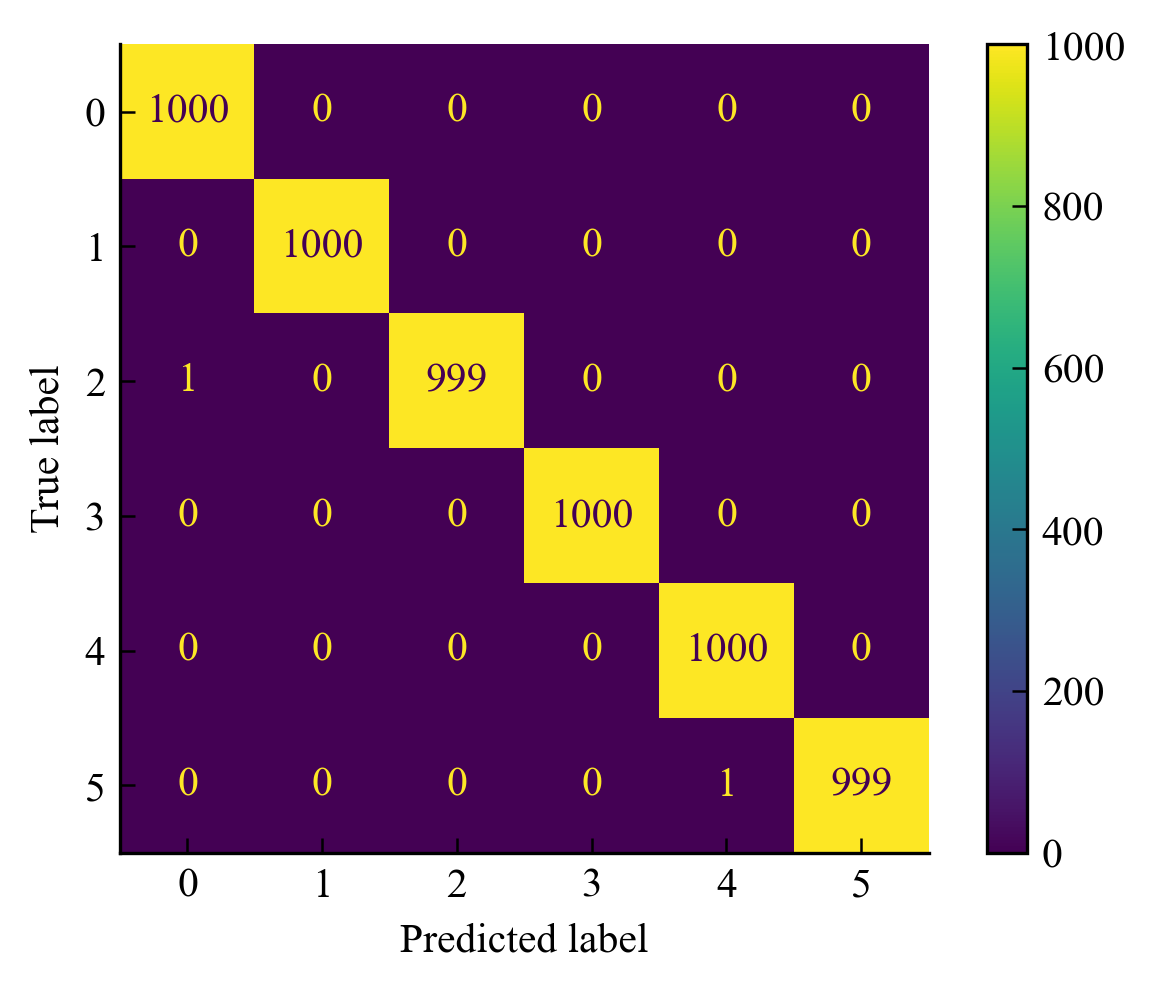

d = 7


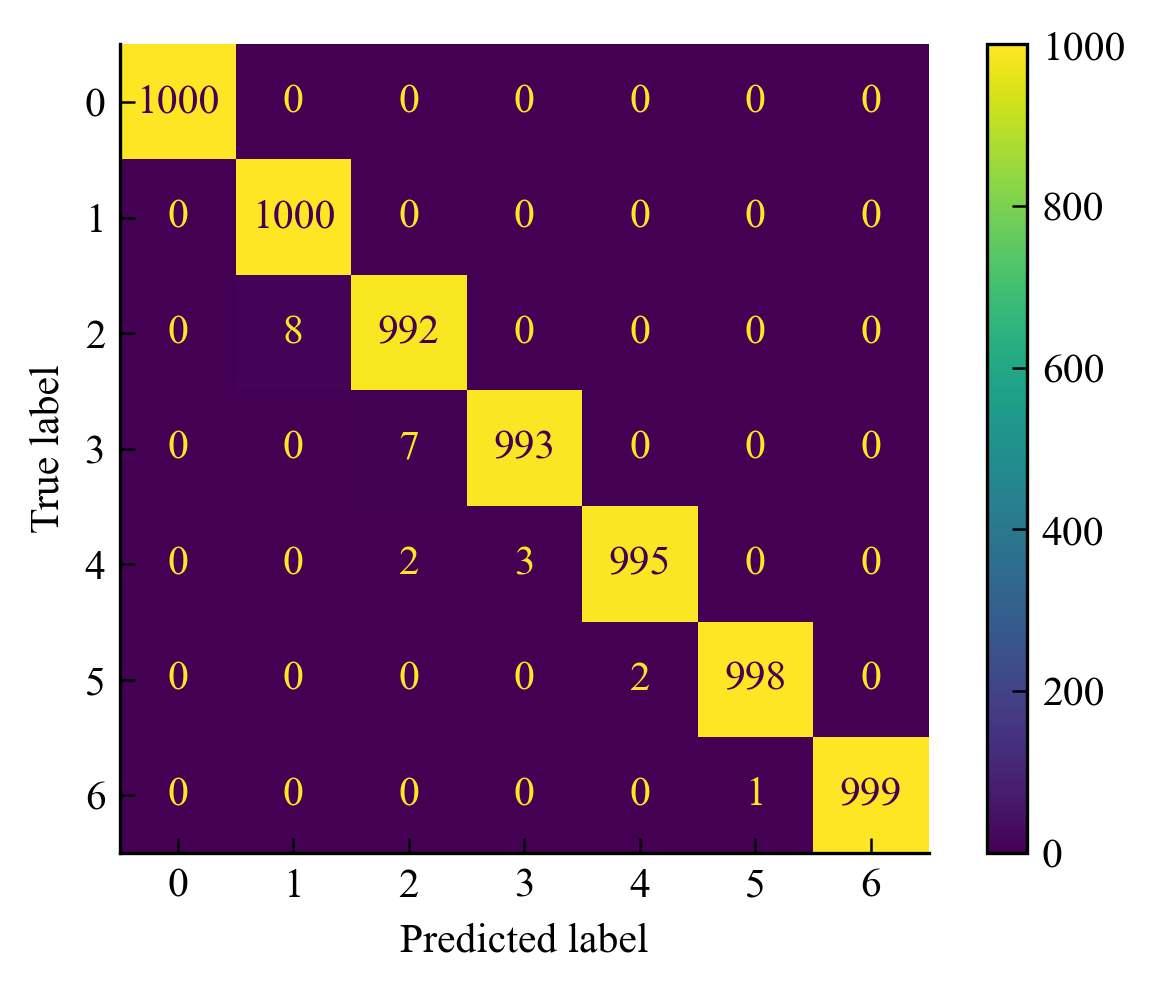

d = 9


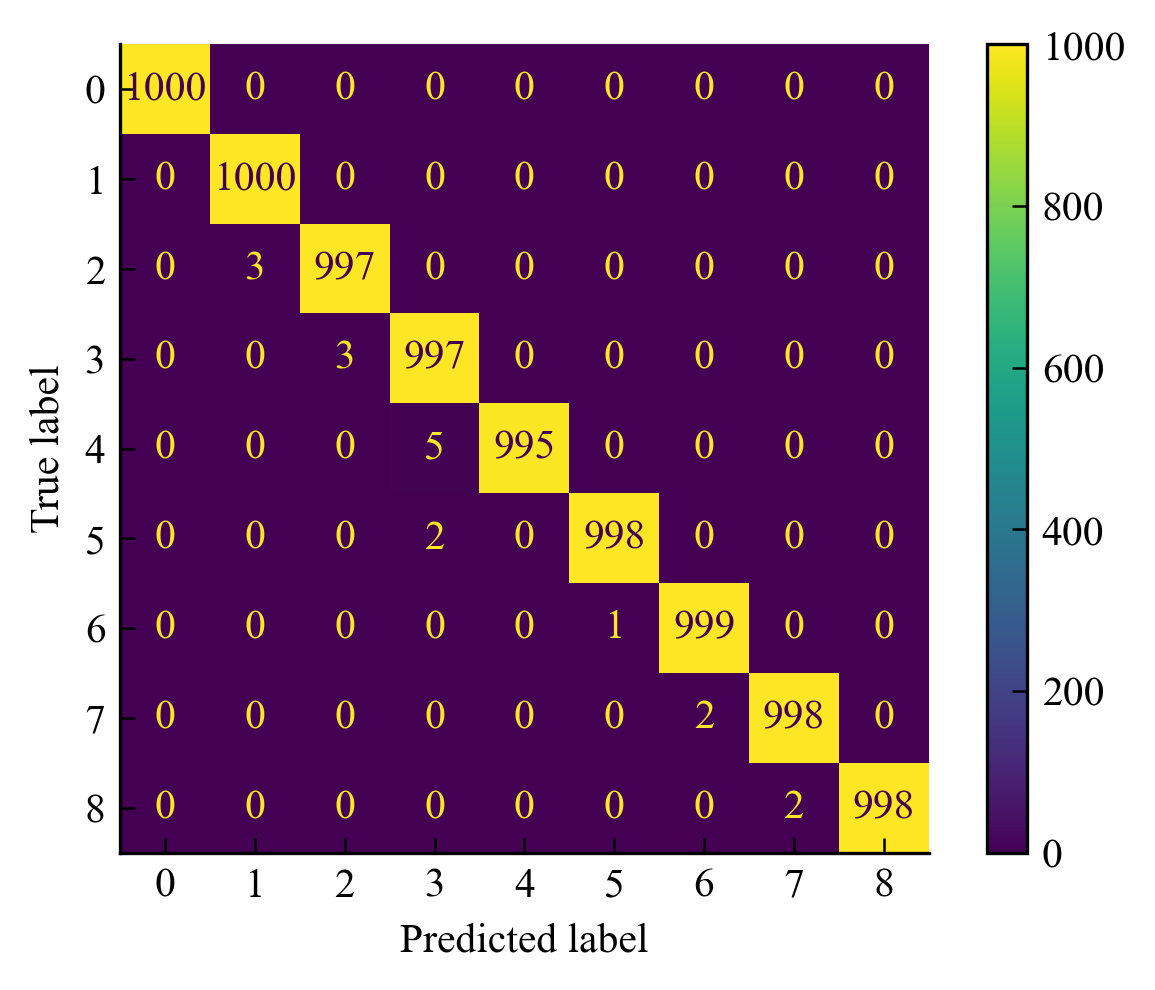

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for filename in os.listdir('./sandbox/jordan8_results'):
    if filename.startswith("results_") and filename.endswith(".json"):
        try:
            d = int(filename.split('_')[1].split('.')[0])
        except ValueError:
            continue
            
        file_path = os.path.join('./sandbox/jordan8_results', filename)
        with open(file_path, 'r') as f:
            results = json.load(f)
        
        for entry in results:
            curr_eps = entry.get("eps")
            if curr_eps == 0:
                print("d =", d)
                preds = entry.get("predicted_classes", [])
                trues = entry.get("true_classes", [])
                cm = confusion_matrix(trues, preds)
                ConfusionMatrixDisplay(cm).plot()
                plt.show()
